# Lab Assignment 11: Data Visualizations
## DS 6001: Practice and Application of Data Science
### Robert Clay Harris (jbm2rt)

### Instructions
Please answer the following questions as completely as possible using text, code, and the results of code as needed. Format your answers in a Jupyter notebook. To receive full credit, make sure you address every part of the problem, and make sure your document is formatted in a clean and professional way.

## Problem 0
Import the following libraries:

In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

## Problem 1
Write a short paragraph that provides a critique of the following data visualizations. What's good about each figure, and what's not good? Pay particular attention to how well the figure communicates information to a general audience and tells a complete story. Make specific references to the ideas discussed in the first section of the Module 11 Jupyter notebook.

### Part a
<img src="https://i.reddituploads.com/09d4079fd0bf453586b8524478aac4fd?fit=max&h=1536&w=1536&s=0d63d22eed3d44a41002007990acdf2c" width='500'>

[1 point]

This chart misrepresents the data by violating the principle of proportional ink. The bar for “Not at all” is visually the tallest, despite representing only 13%—far less than the 34% for “Very.” This distortion misleads the viewer and exaggerates the prevalence of that response. The lack of a labeled y-axis and absence of a zero baseline further obscure the actual proportions. Although the chart includes clear labels and percentages, it fails to communicate the data accurately. The visualization prioritizes visual impact over truthful representation and should be redesigned to match the bar heights to the actual percentages and include proper axes.

### Part b
<img src="https://www.designyourway.net/diverse/2/wronginfo/59426786926.jpg" width='600'>

[1 point]

This pie chart is visually misleading and poorly suited for communicating the data. Although it includes percentage labels and category names, it violates best practices by using a 3D effect, which distorts the actual sizes of the slices. The “Other” category appears disproportionately large due to its placement and perspective, even though it’s not meaningfully distinct in shape from others with lower values. The chart also contains too many categories, making it difficult to compare sectors or identify key takeaways. A horizontal or vertical bar plot would be more effective for comparison, as humans are better at judging length than angles. Additionally, the use of similar shades of blue makes it harder to distinguish between categories, reducing clarity.

### Part c
<img src="https://i.imgur.com/sTVYOIH.jpg" width='400'>

[1 point]

This graph is misleading due to its inverted y-axis, where the origin is at the top and higher numbers are plotted downward. This visual inversion falsely suggests that gun deaths have decreased dramatically when they have not. The chart exploits a psychological bias where upward trends are often associated with increases and downward trends with decreases. While the data points and timeline are labeled, the visual effect distorts interpretation by implying an improvement when the numbers don’t support it. This violates the principle of honest data representation and misleads viewers through visual design, despite using accurate numbers. A standard y-axis with 0 at the bottom would have been more appropriate.

## Problem 2
For the rest of this lab, we will once again be working with the 2019 General Social Survey.

In [3]:
%%capture
gss = pd.read_csv("https://github.com/jkropko/DS-6001/raw/master/localdata/gss2018.csv",
                 encoding='cp1252', na_values=['IAP','IAP,DK,NA,uncodeable', 'NOT SURE',
                                               'DK', 'IAP, DK, NA, uncodeable', '.a', "CAN'T CHOOSE"])

Here is code that cleans the data and gets it ready to be used for data visualizations:

In [4]:
mycols = ['id', 'wtss', 'sex', 'educ', 'region', 'age', 'coninc',
          'prestg10', 'mapres10', 'papres10', 'sei10', 'satjob',
          'fechld', 'fefam', 'fepol', 'fepresch', 'meovrwrk'] 
gss_clean = gss[mycols]
gss_clean = gss_clean.rename({'wtss':'weight', 
                              'educ':'education', 
                              'coninc':'income', 
                              'prestg10':'job_prestige',
                              'mapres10':'mother_job_prestige', 
                              'papres10':'father_job_prestige', 
                              'sei10':'socioeconomic_index', 
                              'fechld':'relationship', 
                              'fefam':'male_breadwinner', 
                              'fehire':'hire_women', 
                              'fejobaff':'preference_hire_women', 
                              'fepol':'men_bettersuited', 
                              'fepresch':'child_suffer',
                              'meovrwrk':'men_overwork'},axis=1)
gss_clean.age = gss_clean.age.replace({'89 or older':'89'})
gss_clean.age = gss_clean.age.astype('float')

The `gss_clean` dataframe now contains the following features:

* `id` - a numeric unique ID for each person who responded to the survey
* `weight` - survey sample weights
* `sex` - male or female
* `education` - years of formal education
* `region` - region of the country where the respondent lives
* `age` - age
* `income` - the respondent's personal annual income
* `job_prestige` - the respondent's occupational prestige score, as measured by the GSS using the methodology described above
* `mother_job_prestige` - the respondent's mother's occupational prestige score, as measured by the GSS using the methodology described above
* `father_job_prestige` -the respondent's father's occupational prestige score, as measured by the GSS using the methodology described above
* `socioeconomic_index` - an index measuring the respondent's socioeconomic status
* `satjob` - responses to "On the whole, how satisfied are you with the work you do?"
* `relationship` - agree or disagree with: "A working mother can establish just as warm and secure a relationship with her children as a mother who does not work."
* `male_breadwinner` - agree or disagree with: "It is much better for everyone involved if the man is the achiever outside the home and the woman takes care of the home and family."
* `men_bettersuited` - agree or disagree with: "Most men are better suited emotionally for politics than are most women."
* `child_suffer` - agree or disagree with: "A preschool child is likely to suffer if his or her mother works."
* `men_overwork` - agree or disagree with: "Family life often suffers because men concentrate too much on their work."

### Part a
Reorder the categories of `relationship` to "strongly agree", "agree", "disagree", and "strongly disagree".

Then create a simple barplot that shows the frequencies of the categories of `relationship` three times: 
* once using `matplotlib` alone, 
* once using `seaborn`, 
* and once using the `.plot()` method from `pandas`. 

Make sure each barplot has descriptive axis labels and a title, and set a good size for each figure displayed in the Jupyter notebook. [2 points]

In [5]:
order = ["strongly agree", "agree", "disagree", "strongly disagree"]
gss_clean['relationship'] = pd.Categorical(gss_clean['relationship'], categories=order, ordered=True)

relationship_counts = gss_clean['relationship'].value_counts().reindex(order)

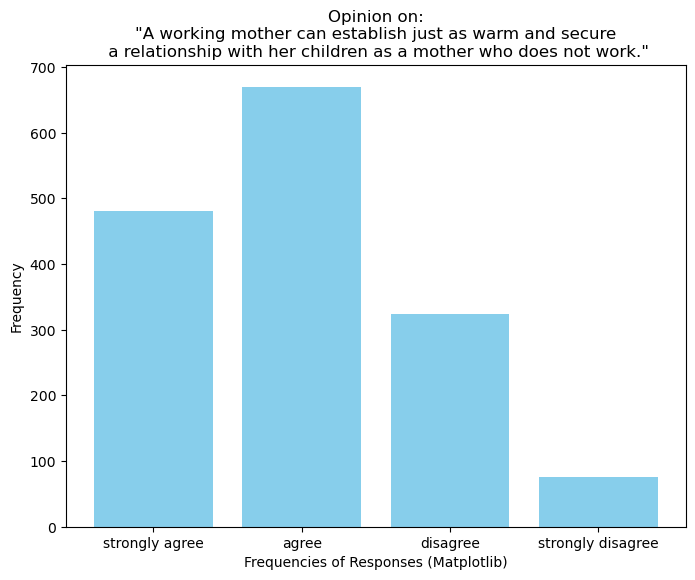

In [6]:
# matplot
plt.figure(figsize=(8, 6))
plt.bar(relationship_counts.index, relationship_counts.values, color='skyblue')
plt.title('Opinion on:\n"A working mother can establish just as warm and secure\n a relationship with her children as a mother who does not work."')
plt.ylabel('Frequency')
plt.xlabel('Frequencies of Responses (Matplotlib)')
plt.show()

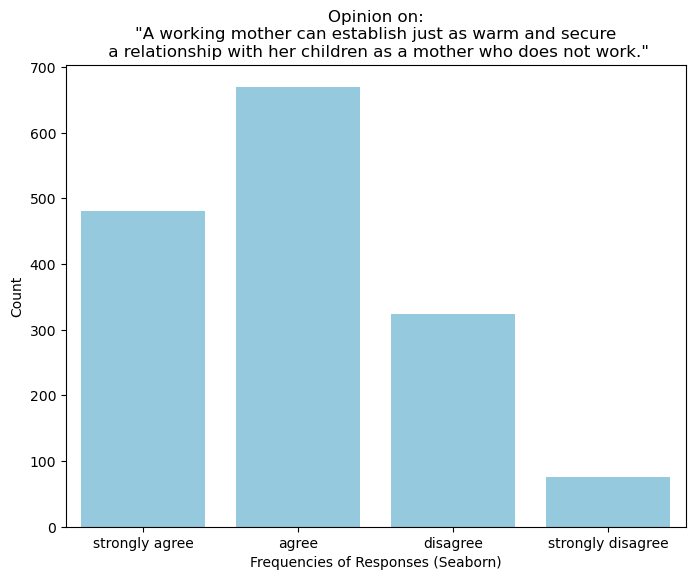

In [7]:
# seaborn
plt.figure(figsize=(8, 6))
sns.countplot(x='relationship', color = 'skyblue', data=gss_clean, order=order, legend = False)
plt.xlabel('Frequencies of Responses (Seaborn)')
plt.ylabel('Count')
plt.title('Opinion on:\n"A working mother can establish just as warm and secure\n a relationship with her children as a mother who does not work."')
plt.show()

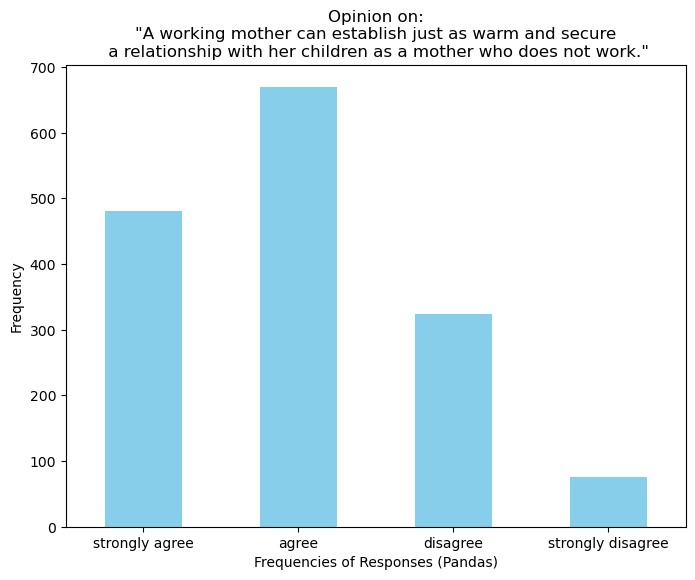

In [8]:
# pandas
plt.figure(figsize=(8, 6))
relationship_counts.plot(kind='bar', color='skyblue', rot=0)
plt.xlabel('Frequencies of Responses (Pandas)')
plt.ylabel('Frequency')
plt.title('Opinion on:\n"A working mother can establish just as warm and secure\n a relationship with her children as a mother who does not work."')
plt.show()

### Part b
Create two barplots that show 
* the frequency of the different levels of agreement for `relationship` for men and for women on the same plot, 
* with bars for men and bars for women side-by-side,
* using different colors for the bars for men and the bars for women,
* listing these colors and the sex they refer to in a legend,
* and labeling each bar with the number the bar represents.

Create the first barplot using `seaborn` with the bars oriented vertically, and create the second barplot using the `.plot()` method with the bars oriented horizontally. [2 points]

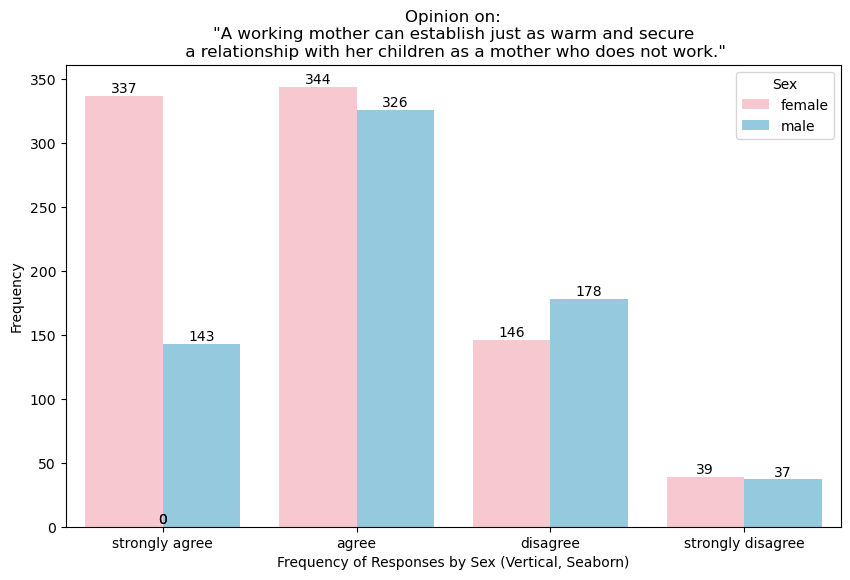

In [9]:
# seaborn
plt.figure(figsize=(10, 6))

ax = sns.countplot(x="relationship", hue="sex", data=gss_clean, 
                   order=order, hue_order=['female', 'male'], 
                   palette={'male': 'skyblue', 'female': 'pink'})
plt.xlabel("Frequency of Responses by Sex (Vertical, Seaborn)")
plt.ylabel("Frequency")
plt.title('Opinion on:\n"A working mother can establish just as warm and secure\n a relationship with her children as a mother who does not work."')
plt.legend(title="Sex")

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2, height, int(height), 
            ha='center', va='bottom', fontsize=10)
plt.show()

/var/folders/fn/36dz4z514cd0cmgsz1j3_f340000gn/T/ipykernel_17614/733428973.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  relationship_sex_counts = gss_clean.groupby(["relationship", "sex"]).size().unstack()


<Figure size 1000x600 with 0 Axes>

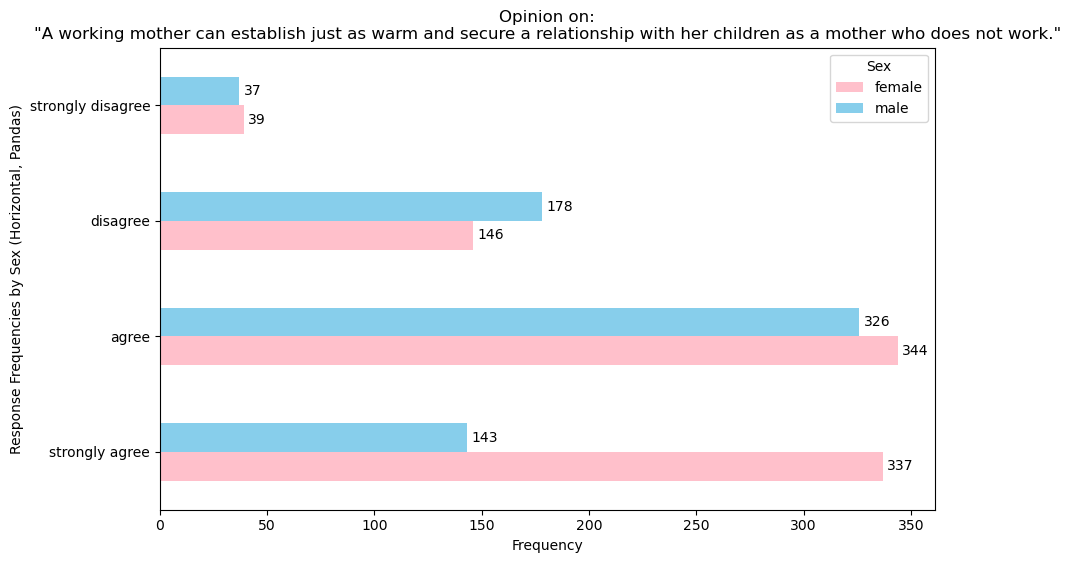

In [10]:
# pandas
relationship_sex_counts = gss_clean.groupby(["relationship", "sex"]).size().unstack()

relationship_sex_counts = relationship_sex_counts.reindex(order)
relationship_sex_counts = relationship_sex_counts[['female', 'male']]

plt.figure(figsize=(10, 6))
ax2 = relationship_sex_counts.plot(kind='barh', color=['pink', 'skyblue'], figsize=(10,6))
plt.xlabel('Frequency')
plt.title('Opinion on:\n"A working mother can establish just as warm and secure a relationship with her children as a mother who does not work."')
plt.ylabel('Response Frequencies by Sex (Horizontal, Pandas)')
plt.legend(title="Sex")

for patch in ax2.patches:
    width = patch.get_width()
    ax2.text(width + 2, patch.get_y() + patch.get_height() / 2, int(width),
             ha='left', va='center', fontsize=10)
    
plt.show()

### Part c
Create a visualization with 
* nine barplots, arranged in a 3x3 grid. 
* The barplots should refer to each of the nine categories of `region`, 
* and each barplot should be given a label that contains the name of the region.
* Within each barplot, list the categories of `relationship`,
* and display horizontal bars.

Only one figure is required. Use `seaborn`, `matplotlib`, and `.plot()` as you see fit. [2 points]

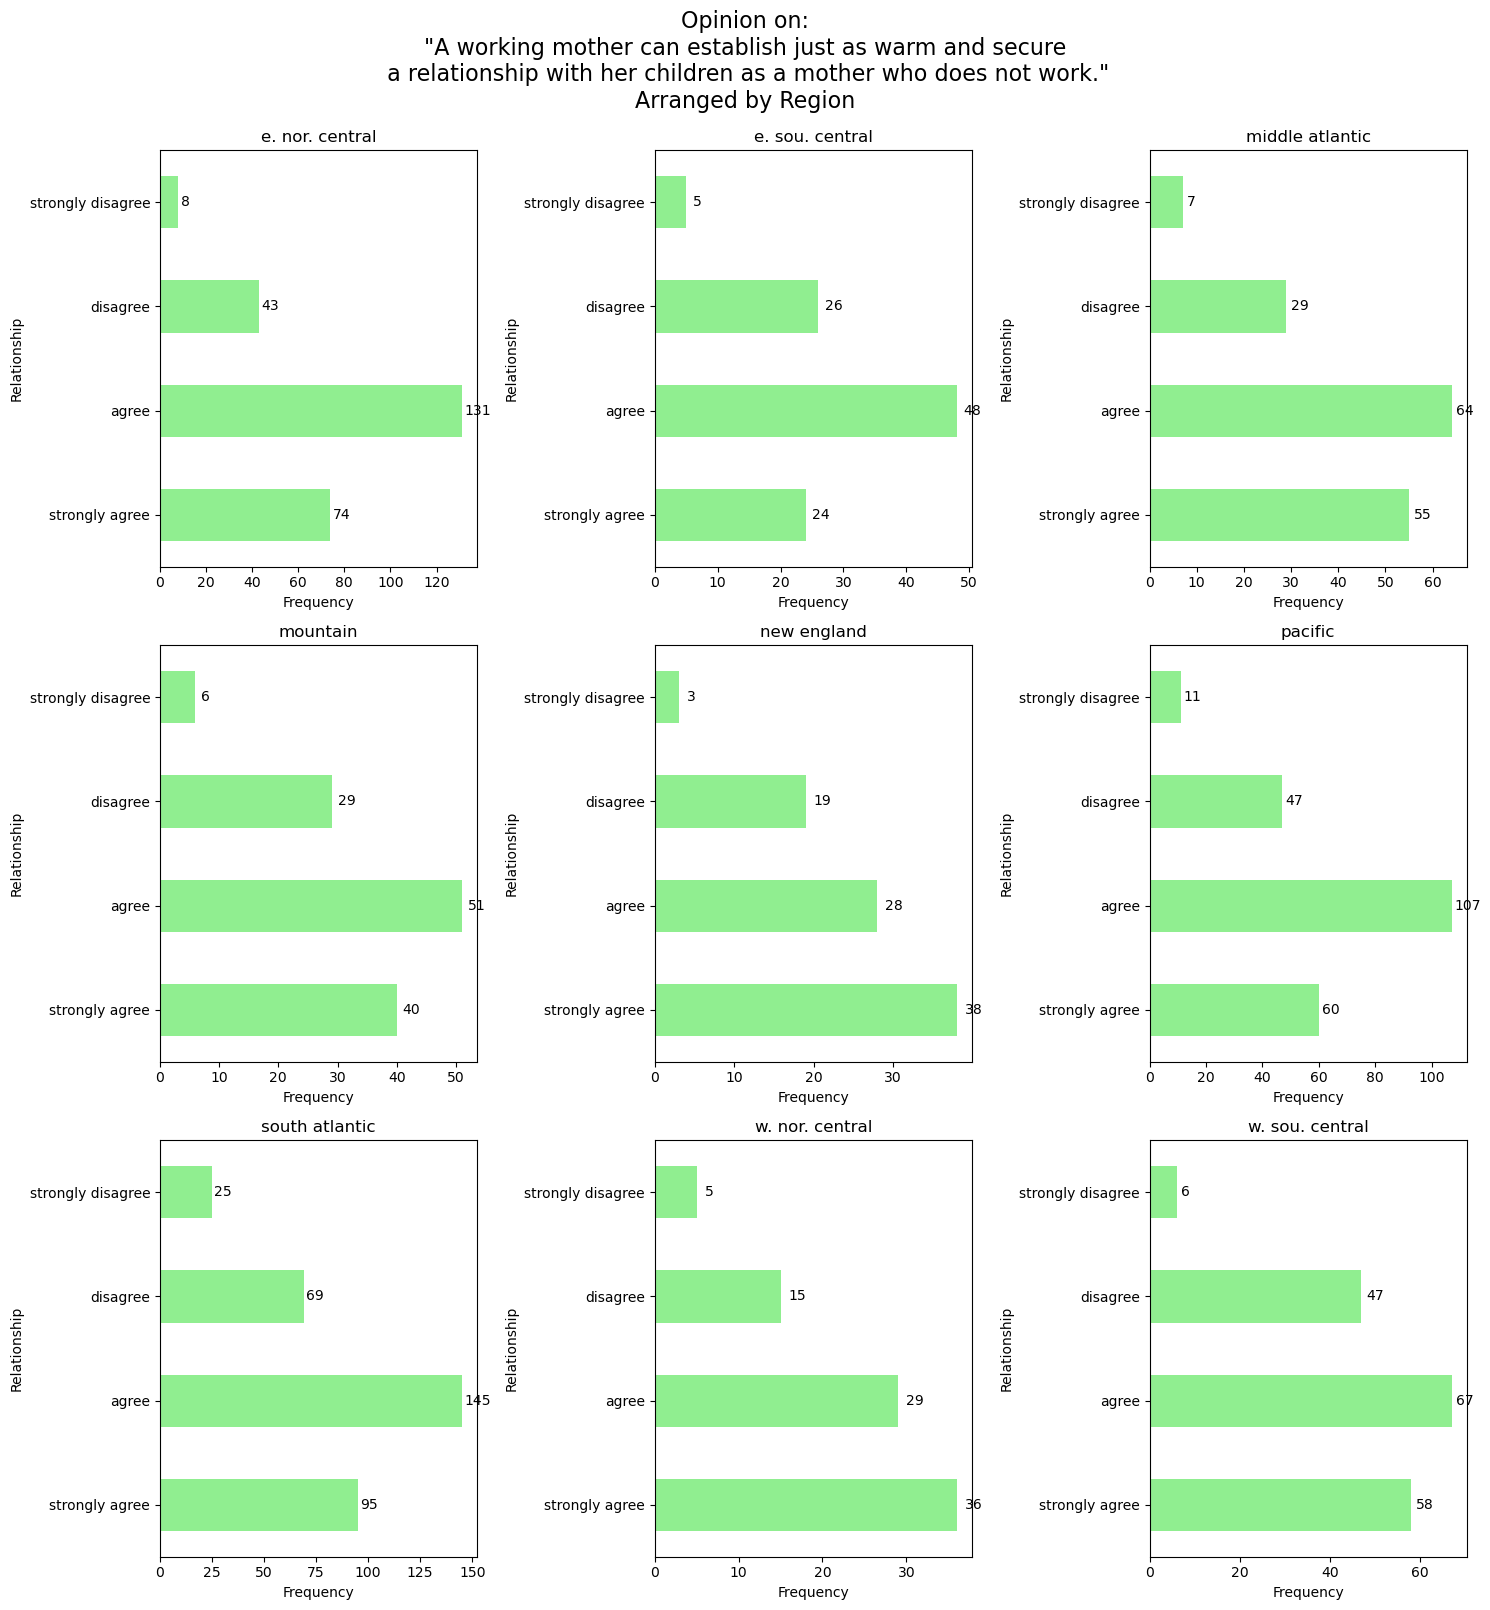

In [17]:
order = ["strongly agree", "agree", "disagree", "strongly disagree"]

regions = sorted(gss_clean['region'].dropna().unique())

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 15))
axes = axes.flatten()

for ax, region in zip(axes, regions):
    region_data = gss_clean[gss_clean['region'] == region]
    
    rel_counts = region_data['relationship'].value_counts().reindex(order).fillna(0)
    
    rel_counts.plot(kind='barh', ax=ax, color='lightgreen')
    
    ax.set_title(region)
    ax.set_xlabel('Frequency')
    ax.set_ylabel('Relationship')
    
    for patch in ax.patches:
        width = patch.get_width()
        ax.text(width + 1, patch.get_y() + patch.get_height() / 2, int(width),
                ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.suptitle('Opinion on:\n"A working mother can establish just as warm and secure\n a relationship with her children as a mother who does not work."\nArranged by Region', fontsize=16, y=1.07)
plt.show()

## Problem 3
Write code that exactly replicates the following figures, including all aesthetic choices. **Don't worry, however, about making the size of the figures exactly the same as that varies from browser to browser.** All of the following figures are generated by a primary graphing function from `seaborn`. 

### Part a
Replicate the following figure:
<img src="https://raw.githubusercontent.com/jkropko/DS-6001/master/localimages/parta.png" width='700'>

[Hint: the values of occuptational prestige and socioeconomic status are the means of `job_prestige` and `socioeconomic_index` within years of `education`. Note that values of `education` less than 8 are excluded.] [2 points]

/var/folders/fn/36dz4z514cd0cmgsz1j3_f340000gn/T/ipykernel_17614/1328510338.py:30: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


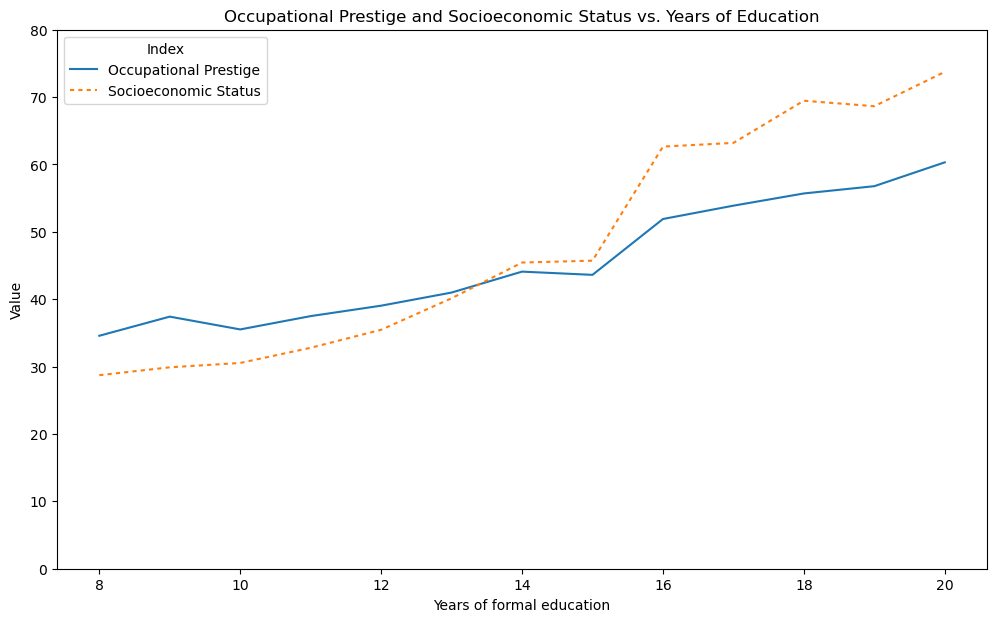

In [ ]:
df_filtered = gss_clean[gss_clean['education'] >= 8].copy()

df_grouped = df_filtered.groupby('education', as_index=False).agg({
    'job_prestige': 'mean',
    'socioeconomic_index': 'mean'
})

df_melt = df_grouped.melt(
    id_vars='education',
    value_vars=['job_prestige', 'socioeconomic_index'],
    var_name='Index',
    value_name='Value'
)

df_melt['Index'] = df_melt['Index'].replace({
    'job_prestige': 'Occupational Prestige',
    'socioeconomic_index': 'Socioeconomic Status'
})

plt.figure(figsize=(12, 7))
sns.lineplot(
    data=df_melt,
    x='education', 
    y='Value',
    hue='Index',
    style='Index',             
    dashes={'Occupational Prestige': '', 
            'Socioeconomic Status': (2, 2)},
    ci=None                    
)

plt.ylim(0, 80)

plt.xlabel('Years of formal education')
plt.ylabel('Value')
plt.title('Occupational Prestige and Socioeconomic Status vs. Years of Education')
plt.legend(title='Index', loc='upper left')
plt.show()

### Part b
Replicate the following figure:
<img src="https://raw.githubusercontent.com/jkropko/DS-6001/master/localimages/partb.png" width='700'>

[Hint: to match the color scheme, you will need to set `center=0`.] [2 points]

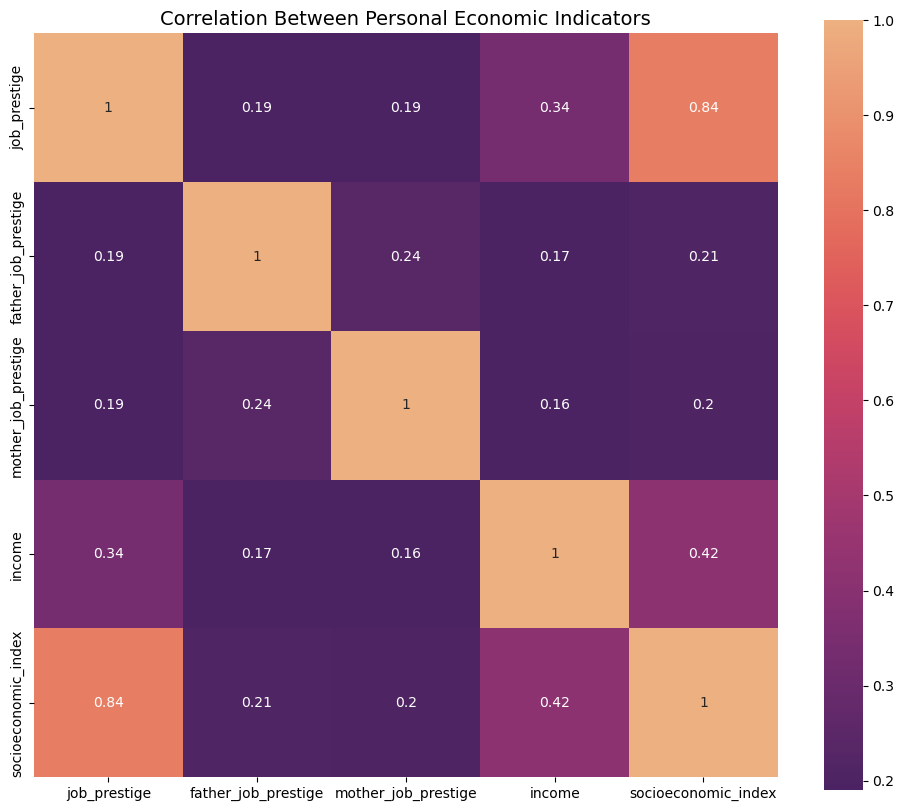

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select the relevant columns
subset = gss_clean[['job_prestige', 
                    'father_job_prestige', 
                    'mother_job_prestige', 
                    'income', 
                    'socioeconomic_index']].copy()

# Compute the correlation matrix
corr_matrix = subset.corr()

# Create the heatmap
plt.figure(figsize=(12,10))
sns.heatmap(
    corr_matrix, 
    annot=True,           # display correlation values in each cell
    cmap=sns.color_palette("flare_r", as_cmap=True),  # use the rocket palette
    vmin=0.19, vmax=1,      # full correlation range
    cbar_kws={"ticks": np.arange(0.2, 1.1, 0.1)},  # colorbar ticks from -1 to 1 every 0.1
    square=True,          # make each cell square
)

plt.title("Correlation Between Personal Economic Indicators", fontsize=14)
plt.show()

### Part c
Replicate the following figure:
<img src="https://raw.githubusercontent.com/jkropko/DS-6001/master/localdata/partc2.png" width='600'>

[Hint: The individual plots inside the grid have `height=4` and `aspect=1`, and to include the overall title I used
```
g.fig.subplots_adjust(top=.95)
g.fig.suptitle('Income vs. Prestige by Education', fontsize=16)
```
You will first need to create a version of `education` that collapses values from 0 to 10 to "10 years or fewer" and collapses values from 17 to 20 to "More than 16 years". You can use `.map()`, `.replace()`, or `pd.cut()` to do that.] [3 points]

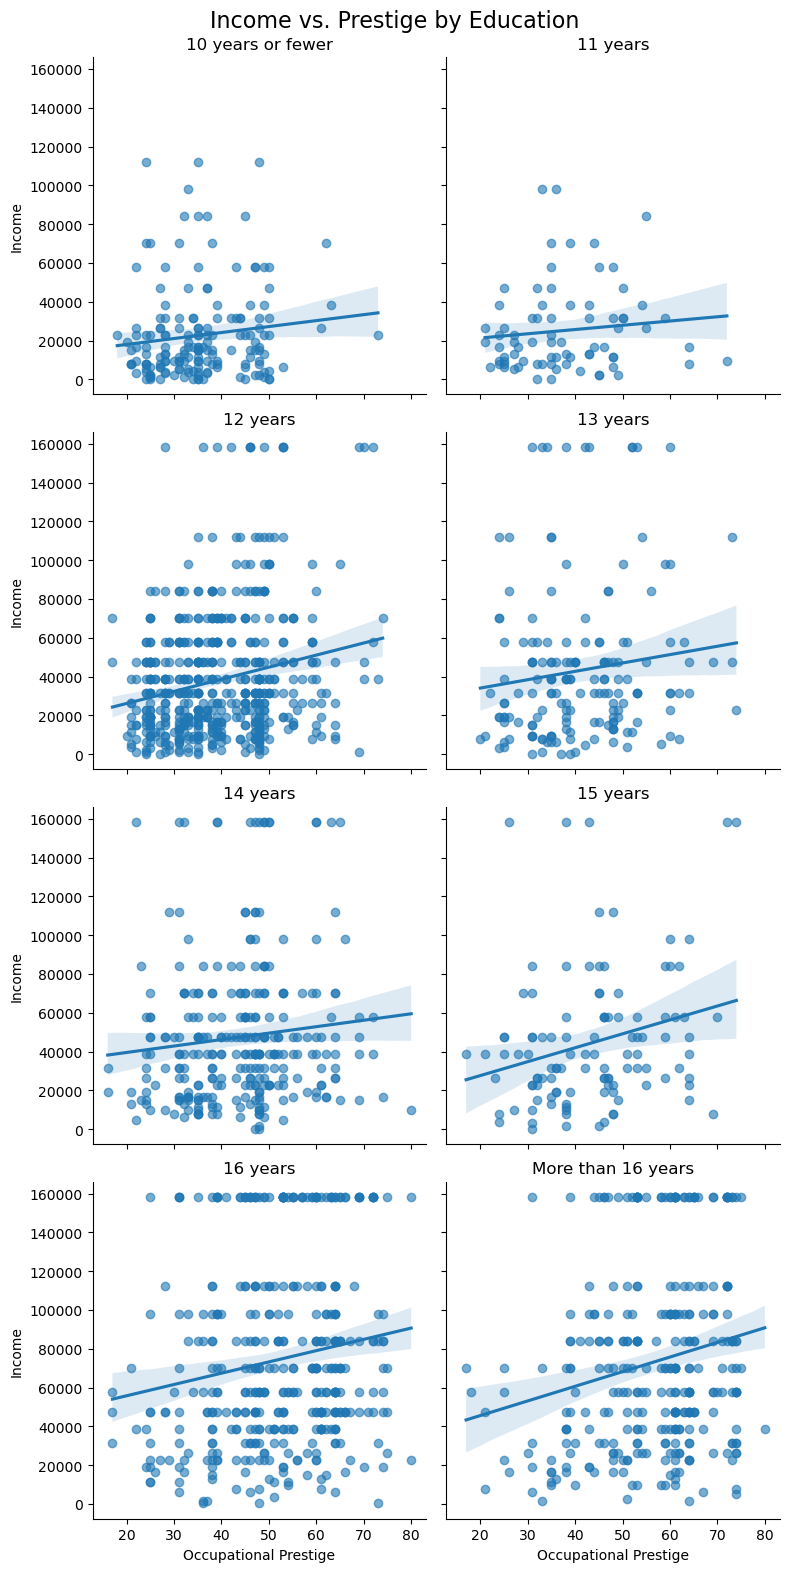

In [50]:
def collapse_education(e):
    if pd.isnull(e):
        return np.nan
    elif e <= 10:
        return '10 years or fewer'
    elif e >= 17:
        return 'More than 16 years'
    else:
        return f'{int(e)} years'

gss_clean['education_collapsed'] = gss_clean['education'].apply(collapse_education)

desired_order = ['10 years or fewer'] + [f'{i} years' for i in range(11, 17)] + ['More than 16 years']

gss_clean['education_collapsed'] = pd.Categorical(gss_clean['education_collapsed'],
                                                  categories=desired_order,
                                                  ordered=True)

g = sns.lmplot(
    data=gss_clean,
    x='job_prestige',
    y='income',
    col='education_collapsed',  
    col_wrap=2,                
    height=4,                   
    aspect=1,                   
    scatter_kws={'alpha': 0.6}  
)

for ax in g.axes.flat:
    new_title = ax.get_title().split('=')[-1].strip()
    ax.set_title(new_title)

g.set_axis_labels('Occupational Prestige', 'Income')

g.fig.subplots_adjust(top=0.95)
g.fig.suptitle('Income vs. Prestige by Education', fontsize=16)

plt.show()

## Problem 4
There is a consistent finding that in the United States that [women get paid only 80% of what men get paid](https://nwlc.org/issue/equal-pay-and-the-wage-gap/). Other research however finds that the gap is much smaller when comparing [men and women who hold the same job](https://www.politifact.com/factchecks/2018/apr/13/tina-smith/do-women-get-only-80-percent-pay-men-do-same-job/). In this problem you will use the GSS data to investigate the following questions:

1. Do men have higher incomes than women?

2. If there is a difference, is this difference due to the fact that men have jobs with higher occupational prestige than women?

You may use any kind of data visualization and you may use multiple visualizations to find an answer to these questions. In order to receive credit for this problem, you must write in text what parts of your visualizations are important and what we should learn from the visualizations to answer the questions. Please consider the entire distributions of income and occupational prestige, not just the means or medians. [4 points]

1. Do men have higher incomes than women?

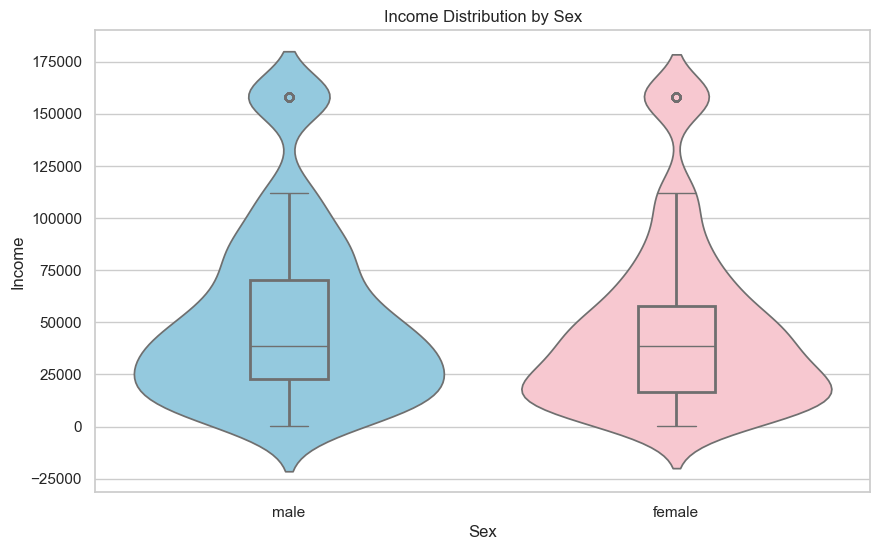

In [55]:
plt.figure(figsize=(10, 6))
sns.violinplot(
    x='sex',
    y='income',
    data=gss_clean,
    hue='sex',
    dodge=False,
    palette={'male': 'skyblue', 'female': 'pink'},
    legend=False,
    inner=None
)

sns.boxplot(
    x='sex',
    y='income',
    data=gss_clean,
    hue='sex',
    dodge=False,
    palette={'male': 'skyblue', 'female': 'pink'},
    legend=False,
    width=0.2,
    showcaps=True,
    boxprops={'facecolor':'none', 'linewidth':2},
    showfliers=True,
    whiskerprops={'linewidth':2}
)

plt.title("Income Distribution by Sex")
plt.xlabel("Sex")
plt.ylabel("Income")
plt.show()

The combined violin and box plot reveals some interesting differences between the income distributions for men and women. Although the box plot shows that the median income is slightly higher for women, the upper quartile (the top of the IQR) is higher for men. This means that even though the central tendency is a bit higher for women, the spread of incomes indicates that a larger proportion of men earn much higher incomes—evidenced by the elevated top of the IQR. Additionally, the violin plot illustrates a higher concentration of observations in the upper range for men, reinforcing that more men appear at the higher end of the income spectrum compared to women.

2. If there is a difference, is this difference due to the fact that men have jobs with higher occupational prestige than women?

/var/folders/fn/36dz4z514cd0cmgsz1j3_f340000gn/T/ipykernel_17614/176878628.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_counts = gss_clean.groupby(['prestige_bin', 'sex']).size().unstack()


<Figure size 1000x600 with 0 Axes>

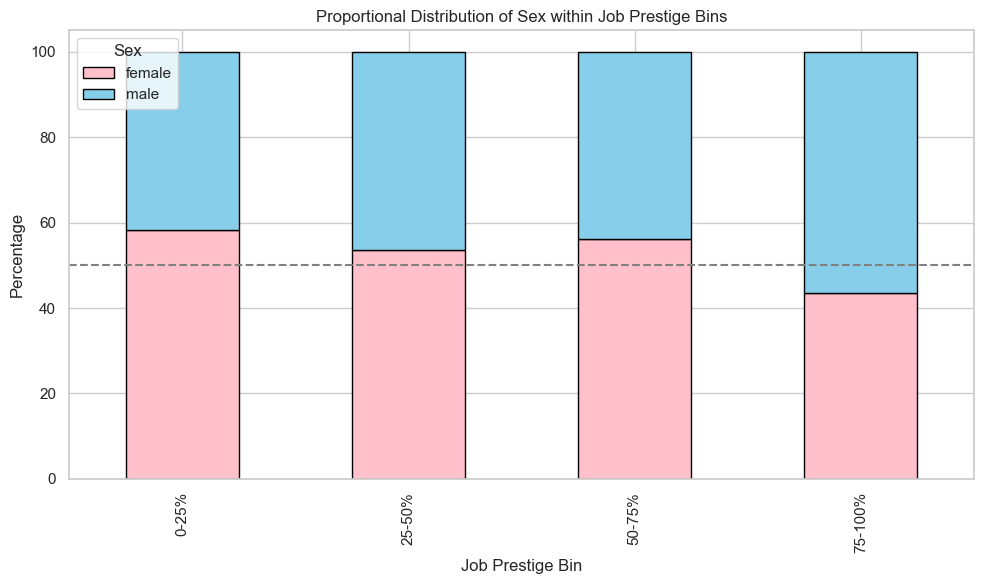

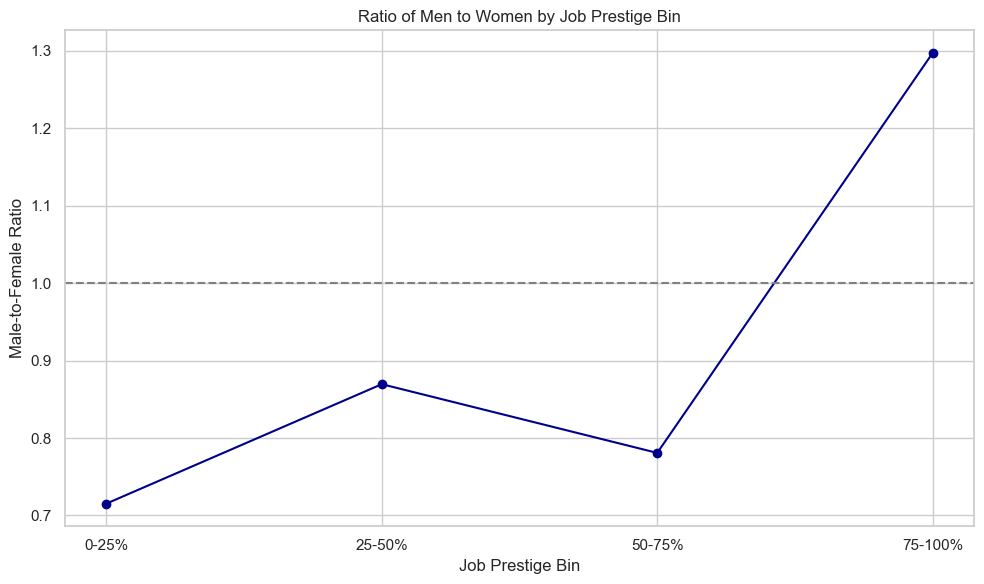

In [60]:
bins = np.linspace(gss_clean['job_prestige'].min(), gss_clean['job_prestige'].max(), 5)

labels = ['0-25%', '25-50%', '50-75%', '75-100%']

gss_clean['prestige_bin'] = pd.cut(gss_clean['job_prestige'], bins=bins, include_lowest=True, labels=labels)

bin_counts = gss_clean.groupby(['prestige_bin', 'sex']).size().unstack()

bin_pct = bin_counts.div(bin_counts.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 6))
ax1 = bin_pct.plot(kind='bar', stacked=True,
                   color={'male': 'skyblue', 'female': 'pink'},
                   edgecolor='black',
                   figsize=(10,6))
plt.xlabel('Job Prestige Bin')
plt.ylabel('Percentage')
plt.title('Proportional Distribution of Sex within Job Prestige Bins')
plt.axhline(50, color='grey', linestyle='--')
plt.legend(title='Sex', loc='upper left')
plt.tight_layout()
plt.show()

ratio = bin_counts['male'] / bin_counts['female']

plt.figure(figsize=(10, 6))
plt.plot(ratio.index.astype(str), ratio, marker='o', linestyle='-', color='darkblue')
plt.xlabel('Job Prestige Bin')
plt.ylabel('Male-to-Female Ratio')
plt.title('Ratio of Men to Women by Job Prestige Bin')
plt.axhline(1, color='grey', linestyle='--')
plt.tight_layout()
plt.show()

The stacked bar chart shows the proportional distribution of men and women across four job prestige bins. In the bottom three bins—representing the lowest 75% of the job prestige range—women constitute a higher percentage of the sample. In contrast, the top bin (75–100% of the job prestige range) is dominated by men, with a significantly higher proportion of male respondents.

This finding is reinforced by the line plot of the male-to-female ratio. In the lower three bins, the ratio is below 1, indicating that for those levels of job prestige, there are fewer men than women. In the highest bin, however, the ratio rises sharply above 1, demonstrating that men are significantly overrepresented in the top 25% of job prestige.

Together, these plots suggest that differences in occupational prestige between men and women are evident—women are more common in jobs with lower prestige scores, while men tend to occupy the highest-prestige positions. This distributional difference may contribute to the overall income gap, as higher job prestige is typically associated with higher earnings.